# Step 1: Data Collection

## Objective

The first step in any machine learning project is to collect the required dataset.

For this project, the **Medical Insurance Charges Dataset** is used. The dataset contains demographic and health-related information about customers along with their medical insurance charges.

## Dataset Features

- **Age** – Age of the customer.
- **Sex** – Gender of the customer.
- **BMI** – Body Mass Index.
- **Children** – Number of dependent children.
- **Smoker** – Smoking status.
- **Region** – Residential region.
- **Charges** – Medical insurance cost (Target Variable).

## Goal

The objective is to build a machine learning model that predicts insurance charges based on customer information.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import pickle 
import warnings

warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('insurance.csv')

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


# Step 2: Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis helps understand the dataset by identifying patterns, relationships, and trends.

## Analysis Performed

- Statistical summary of numerical features.
- Distribution of insurance charges.
- Correlation analysis.
- Relationship between BMI and charges.
- Impact of smoking on insurance charges.
- Gender-wise comparison.
- Region-wise comparison.
- Outlier detection.

## Visualization Techniques

- Histogram
- Box Plot
- Count Plot
- Scatter Plot
- Heatmap
- Pair Plot

## Outcome

EDA provided valuable insights into the factors that significantly influence insurance charges.

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

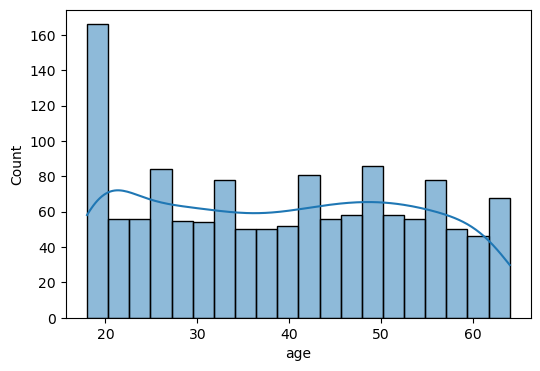

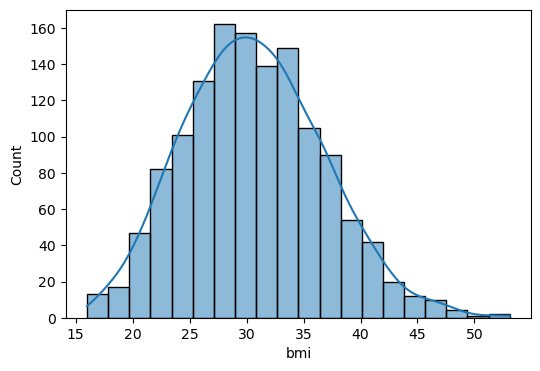

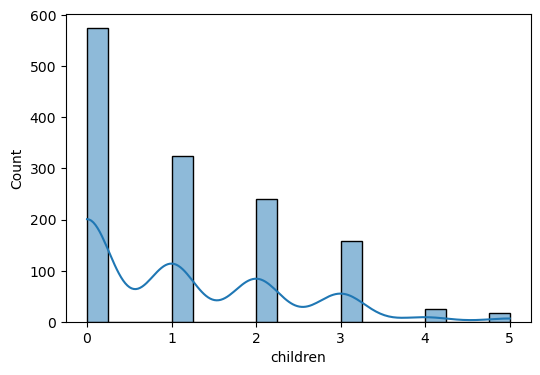

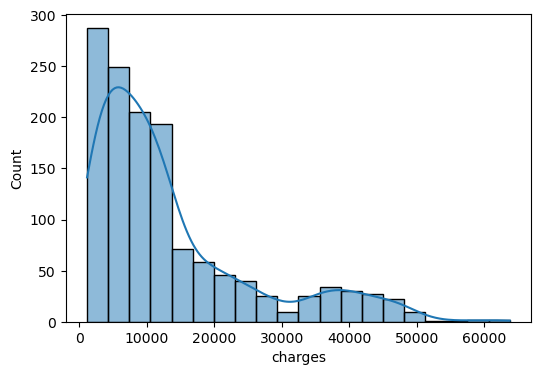

In [9]:
numeric_colunms=['age',  'bmi', 'children', 'charges']
for col in numeric_colunms:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)
    

<Axes: xlabel='children', ylabel='count'>

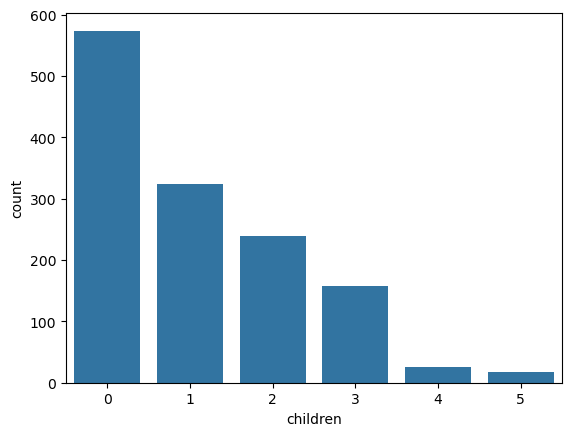

In [10]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

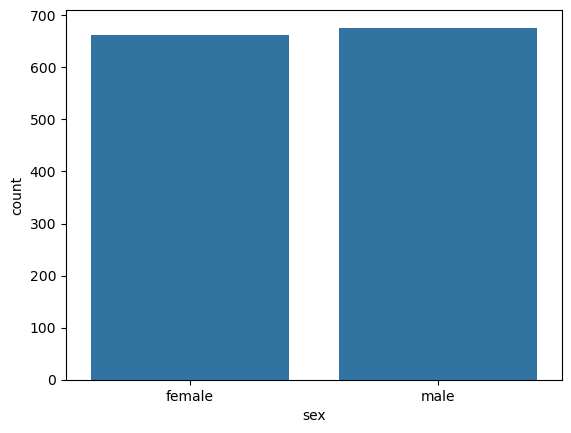

In [11]:
sns.countplot(x=df['sex'])

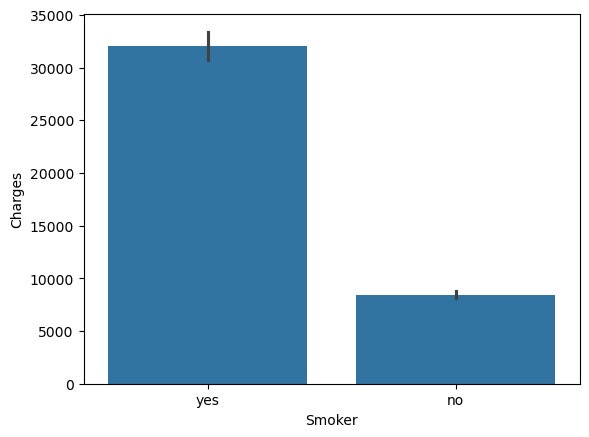

In [12]:
sns.barplot(x='smoker', y='charges', data=df)
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

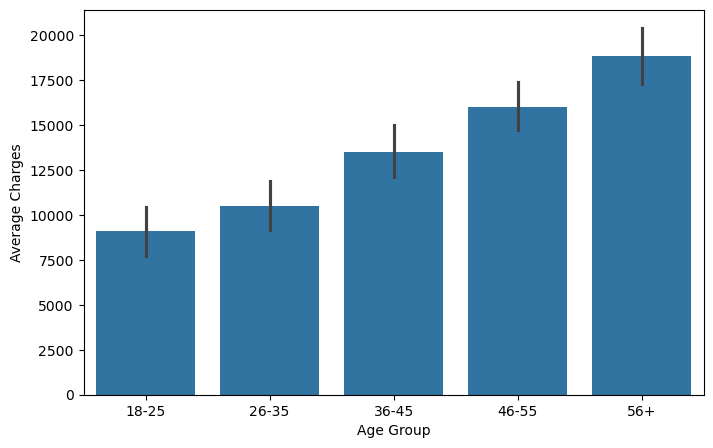

In [13]:
# Create Age Bins
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56+']

df['Age_Group'] = pd.cut(df['age'], bins=bins, labels=labels, include_lowest=True)

# Plot Average Charges by Age Group
plt.figure(figsize=(8,5))
sns.barplot(x='Age_Group', y='charges', data=df, estimator='mean')
plt.xlabel("Age Group")
plt.ylabel("Average Charges")
plt.show()

In [14]:
df.drop(columns=['Age_Group'], inplace=True)
print("Age_Group deleted")

Age_Group deleted


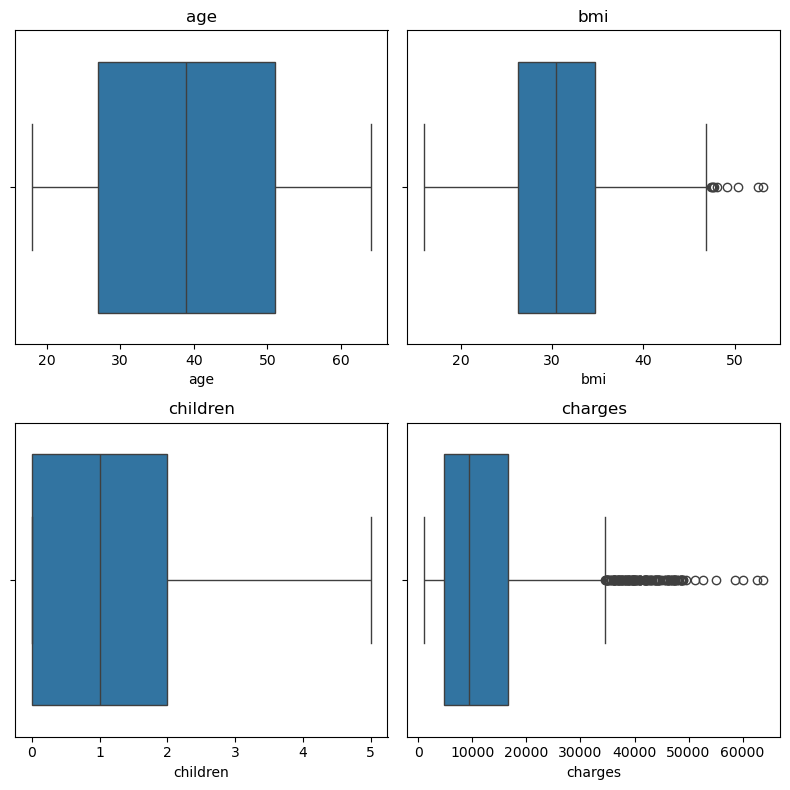

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, col in zip(axes.flatten(), numeric_colunms):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

<Axes: >

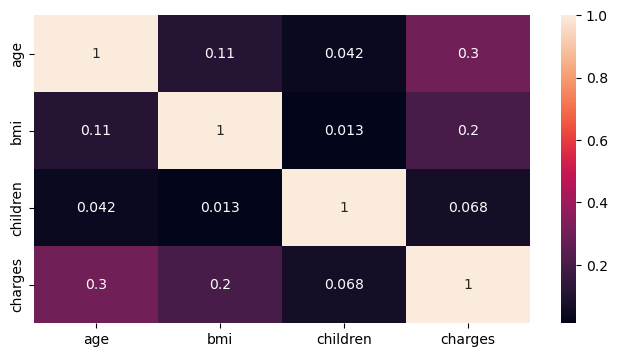

In [16]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Step 3: Data Cleaning and Data Preprocessing

## Objective

Raw datasets often contain inconsistencies that can negatively affect model performance.

Data cleaning improves data quality before analysis and model training.

## Cleaning Operations Performed

- Loaded the dataset into Pandas.
- Checked dataset dimensions.
- Examined data types.
- Verified missing values.
- Removed duplicate records.
- Validated column values.
- Corrected inconsistent data where necessary.

## Outcome

The cleaned dataset is reliable and ready for Exploratory Data Analysis (EDA).

In [17]:
df_cleaned=df.copy()

In [18]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [19]:
df_cleaned.shape

(1338, 7)

In [20]:
df_cleaned.drop_duplicates(inplace=True)

In [21]:
df_cleaned.shape

(1337, 7)

In [22]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [23]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [24]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [25]:
df_cleaned['sex']=df_cleaned['sex'].map({'male':0,'female':1})

In [26]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.9,0,yes,southwest,16884.92
1,18,0,33.8,1,no,southeast,1725.55
2,28,0,33.0,3,no,southeast,4449.46
3,33,0,22.7,0,no,northwest,21984.47
4,32,0,28.9,0,no,northwest,3866.86


In [27]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [28]:
df_cleaned['smoker']=df_cleaned['smoker'].map({'yes':1,'no':0})

In [29]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.9,0,1,southwest,16884.92
1,18,0,33.8,1,0,southeast,1725.55
2,28,0,33.0,3,0,southeast,4449.46
3,33,0,22.7,0,0,northwest,21984.47
4,32,0,28.9,0,0,northwest,3866.86


In [30]:
df_cleaned.rename(columns={'sex':'is_feamle','smoker':'is_smoker'},inplace=True)

In [31]:
df_cleaned.head()

,age,is_feamle,bmi,children,is_smoker,region,charges
0,19,1,27.9,0,1,southwest,16884.92
1,18,0,33.8,1,0,southeast,1725.55
2,28,0,33.0,3,0,southeast,4449.46
3,33,0,22.7,0,0,northwest,21984.47
4,32,0,28.9,0,0,northwest,3866.86


In [32]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [33]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [34]:
df_cleaned.head()

,age,is_feamle,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.9,0,1,16884.92,False,False,True
1,18,0,33.8,1,0,1725.55,False,True,False
2,28,0,33.0,3,0,4449.46,False,True,False
3,33,0,22.7,0,0,21984.47,True,False,False
4,32,0,28.9,0,0,3866.86,True,False,False


In [35]:
df_cleaned = df_cleaned.astype(int)

In [36]:
df_cleaned.head()

,age,is_feamle,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0



# Step 4: Feature Engineering , Extraction and Scaling

## Objective

Feature Engineering improves model performance by transforming raw data into meaningful input features.

## Techniques Applied

- Converted categorical variables into numerical values.
- Applied One-Hot Encoding for categorical features.
- Created BMI Category feature.
- Selected important features.
- Standardized feature format.
- Prepared the final dataset for machine learning.

## Final Features

The final dataset contains only the relevant features required for model training while maintaining the target variable (Insurance Charges).

## Outcome

The processed dataset is now ready for splitting into training and testing datasets.

<Axes: xlabel='bmi', ylabel='Count'>

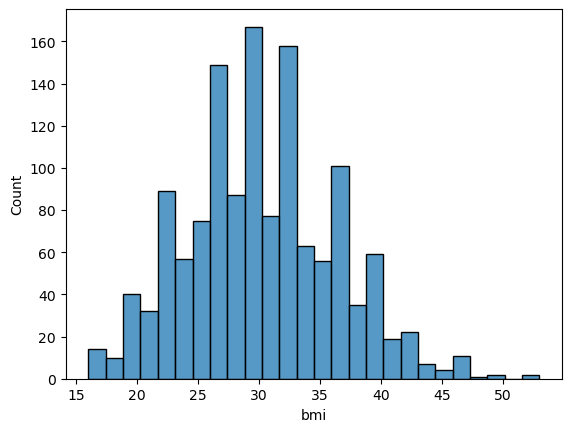

In [37]:
sns.histplot(df_cleaned['bmi'])

In [38]:
df_cleaned['bmi_category']=pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['Underweight','Normal','Overweight','Obese'])

In [39]:
df_cleaned

,age,is_feamle,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,31,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [40]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [41]:
df_cleaned=df_cleaned.astype(int)
df_cleaned.head()

,age,is_feamle,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [42]:
df_cleaned.columns

Index(['age', 'is_feamle', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [43]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler=StandardScaler()

df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [44]:
df_cleaned.head()

,age,is_feamle,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.524321,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.457496,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.457496,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.342502,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.360685,-0.909234,0,3866,1,0,0,0,1,0


In [45]:
df_cleaned.columns

Index(['age', 'is_feamle', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [46]:
from scipy.stats import pearsonr

#------------------------------
#pearson correlation calculation
#-------------------------------

#List of features to check against target
selected_features=['age', 'is_feamle', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese']

correlations={
    feature:pearsonr(df_cleaned[feature],df_cleaned['charges'])[0]
    for feature in selected_features
}
correlations_df=pd.DataFrame(list(correlations.items()),columns=['Feature','pearson Correlation'])
correlations_df.sort_values(by='pearson Correlation',ascending=False)

,Feature,pearson Correlation
5,charges,1.000000
4,is_smoker,0.787234
0,age,0.298309
11,bmi_category_Obese,0.200347
2,bmi,0.197714
7,region_southeast,0.073577
3,children,0.067390
6,region_northwest,-0.038695
8,region_southwest,-0.043637
1,is_feamle,-0.058046


### above 0.5 and below -0.5 is the good correlation
### between 0.2 & (-0.2) and 0.5 & (-0.5) is okay 
### between 0.1 & (-0.1) and 0.2 & (-0.2) is negosabil

In [47]:
cat_features=['is_feamle','is_smoker','region_northwest','region_southeast','region_southwest','bmi_category_Normal','bmi_category_Overweight','bmi_category_Obese']


In [48]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha=0.05

df_cleaned['charges_bin']=pd.qcut(df_cleaned['charges'],q=4,labels=False)
chi2_result={}

for col in cat_features:
    contingency=pd.crosstab(df_cleaned[col],df_cleaned['charges_bin'])
    chi2_stat,p_val,_,_=chi2_contingency(contingency)
    decision = "Reject Null (Keep Feature)" if p_val < alpha else 'Accept Null(Drop Feature)'
    chi2_result[col]={
        'chi2_statistics':chi2_stat,
        'p_value':p_val,
        'Decision':decision
    }
chi2_df=pd.DataFrame(chi2_result).T
chi2_df=chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistics,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_feamle,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null(Drop Feature)
bmi_category_Overweight,4.873307,0.181313,Accept Null(Drop Feature)
bmi_category_Normal,4.231793,0.237498,Accept Null(Drop Feature)
region_northwest,1.13424,0.768815,Accept Null(Drop Feature)


In [49]:
final_df = df_cleaned[['age','is_feamle','bmi','children','is_smoker','charges','region_southeast','bmi_category_Obese']]
final_df.head()

,age,is_feamle,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1,-0.524321,-0.909234,1,16884,0,0
1,-1.511647,0,0.457496,-0.079442,0,1725,1,1
2,-0.799350,0,0.457496,1.580143,0,4449,1,1
3,-0.443201,0,-1.342502,-0.909234,0,21984,0,0
4,-0.514431,0,-0.360685,-0.909234,0,3866,0,0


In [50]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


# Step 5: Split Data into Training and Testing Sets

The dataset is divided into training and testing datasets.

- **Training Set (80%)** is used to train the machine learning models.
- **Testing Set (20%)** is used to evaluate model performance on unseen data.

This helps determine how well the model generalizes to new data.

In [51]:
from sklearn.model_selection import train_test_split

# Features and Target
X = final_df.drop("charges", axis=1)
y = final_df["charges"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1069, 7)
Testing Features  : (268, 7)
Training Labels   : (1069,)
Testing Labels    : (268,)


# Step 6: Model Training

In this step, multiple machine learning regression algorithms are trained.

The models used are:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Training multiple models helps identify the best-performing algorithm for predicting insurance charges.

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Create Models
lr = LinearRegression()

dt = DecisionTreeRegressor(
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train Models
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


# Step 7: Model Evaluation

The trained models are evaluated using different performance metrics.

Evaluation Metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The best model is selected based on the highest R² Score and lowest error values.

In [53]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np
import pandas as pd

models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

results = []

for name, model in models.items():

    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model","MAE","RMSE","R2 Score"]
)


results_df.sort_values("R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
2,Random Forest,2869.741573,4948.270327,0.866751
0,Linear Regression,4294.939713,6000.437042,0.804060
1,Decision Tree,3495.253109,6989.146220,0.734169



========== FEATURE IMPORTANCE ==========

              Feature  Importance
4           is_smoker    0.599902
0                 age    0.151808
2                 bmi    0.129120
6  bmi_category_Obese    0.069148
3            children    0.027654
1           is_feamle    0.011678
5    region_southeast    0.010691


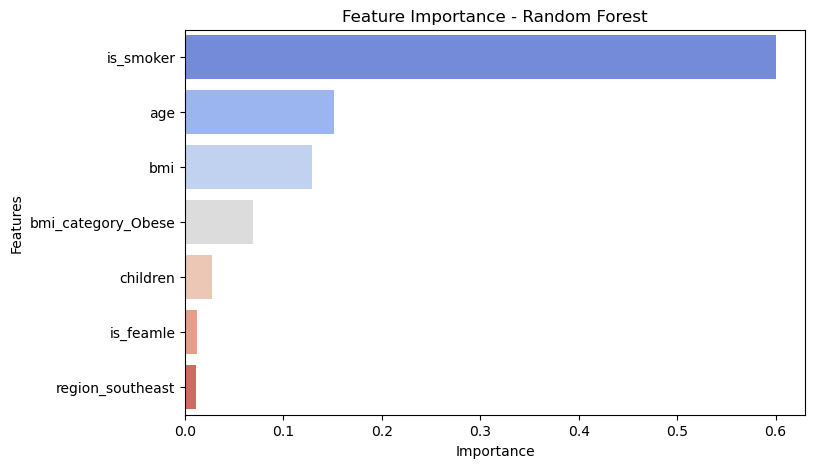

In [54]:
# Feature Importance (Random Forest)
# ------------------------------
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========\n")
print(feature_importance)

plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance,
    palette="coolwarm"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()



# Step 8: Save the Best Model

After comparing all models, the best-performing model is saved using the Joblib library.

The saved model can later be used without retraining.

In [55]:
import pickle
filename="insurance_model.sav"
pickle.dump(rf,open(filename,'wb'))

# Step 9: Prediction on New Customer Data

The saved model is used to predict insurance charges for a new customer.

The prediction demonstrates how the trained model can estimate insurance costs based on customer information.

In [56]:
new_customer = [[
    35,
    0,
    28.5,
    2,
    1,
    0,
    0
]]

prediction = rf.predict(new_customer)

print("Predicted Insurance Charge : ₹", prediction[0])

Predicted Insurance Charge : ₹ 39916.715


In [57]:
# Check Feature Order
print(X.columns)

Index(['age', 'is_feamle', 'bmi', 'children', 'is_smoker', 'region_southeast',
       'bmi_category_Obese'],
      dtype='object')


# Step 10: Model Deployment

The final machine learning model is deployed using Streamlit.

Deployment allows users to enter customer information through a web interface and instantly receive predicted insurance charges.

Deployment Process:

1. Load the saved model.
2. Create input fields for customer information.
3. Predict insurance charges.
4. Display the prediction.

In [58]:
loaded_model=pickle.load(open("insurance_model.sav",'rb'))

In [59]:
final_df.columns

Index(['age', 'is_feamle', 'bmi', 'children', 'is_smoker', 'charges',
       'region_southeast', 'bmi_category_Obese'],
      dtype='object')

In [60]:
new_customer = [[
    35,
    0,
    28.5,
    2,
    1,
    0,
    0
]]

prediction = loaded_model.predict(new_customer)

print("Predicted Insurance Charge : ₹", prediction[0])

Predicted Insurance Charge : ₹ 39916.715


# Conclusion

The insurance charge prediction project was successfully completed using machine learning techniques.

The project followed the complete machine learning pipeline:

- Data Collection
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Train-Test Split
- Model Training
- Model Evaluation
- Model Saving
- Prediction on New Data
- Deployment using Streamlit

Among all trained models, **Random Forest Regressor** provided the best predictive performance and was selected as the final model.

The developed system can assist insurance companies in estimating medical insurance charges efficiently and accurately.